In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# 1 
df = pd.read_csv("Pharmaceutical Supply Chain Optimization.csv")
print(df.head())

           Drug  Demand_Forecast  Optimal_Stock_Level Restocking_Strategy
0     Metformin             7750                 4753             Monthly
1    Lisinopril             5136                 9965           Quarterly
2     Metformin             3183                 2933             Monthly
3       Insulin             2332                 3927             Monthly
4  Atorvastatin             3522                 6812             Monthly


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB
None


In [4]:
print(df.describe())

       Demand_Forecast  Optimal_Stock_Level
count    100000.000000        100000.000000
mean       5489.372180          6270.155320
std        2597.544993          2744.393068
min        1000.000000          1500.000000
25%        3243.000000          3899.750000
50%        5487.000000          6278.000000
75%        7738.000000          8660.000000
max        9999.000000         10999.000000


In [6]:
# 2 
print(df.isnull().sum())

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64


In [ ]:
# 3
numeric_cols = ["Demand_Forecast", "Optimal_Stock_Level"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]
print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (100000, 4)


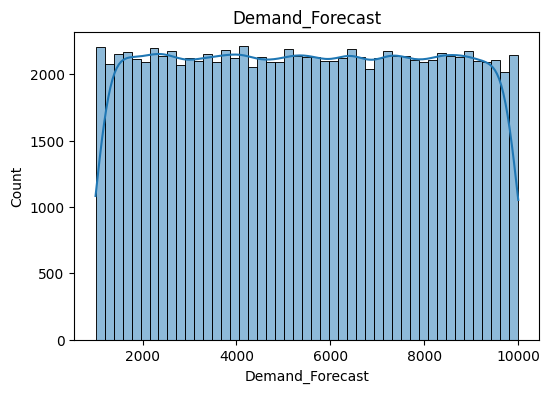

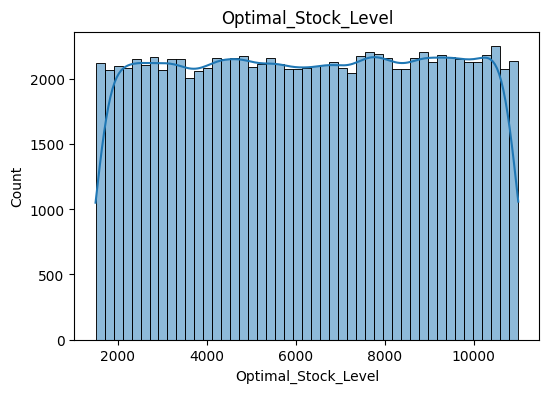

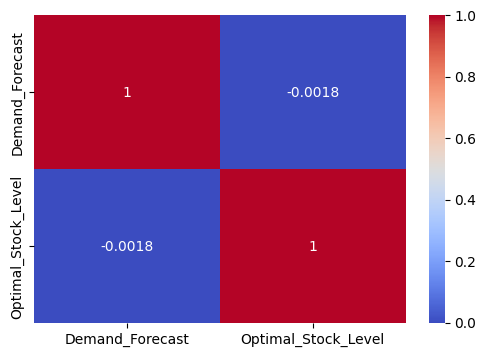

In [ ]:
# 4
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap="coolwarm")
plt.show()

In [ ]:
# 5 

df["Demand_Stock_Ratio"] = (df["Demand_Forecast"] / df["Optimal_Stock_Level"])
df["Demand_Band"] = pd.cut(df["Demand_Forecast"],bins=3,labels=["Low","Medium","High"])

In [10]:
# 6
le = LabelEncoder()

df["Drug"] = le.fit_transform(df["Drug"])
df["Restocking_Strategy"] = le.fit_transform(df["Restocking_Strategy"])
df["Demand_Band"] = le.fit_transform(df["Demand_Band"])

In [11]:
# 7

X = df.drop("Optimal_Stock_Level", axis=1)
y = df["Optimal_Stock_Level"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [ ]:
# 8 
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLinear Regression")
print("RMSE:",np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:",r2_score(y_test, lr_pred))


Linear Regression
RMSE: 1658.1048663375302
R2: 0.6332911368148505


In [ ]:
# 9
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nRandom Forest")
print("RMSE:",np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:",r2_score(y_test, rf_pred))


Random Forest
RMSE: 15.289940005932007
R2: 0.9999688176399633


In [14]:
# 10 
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

print("\nGradient Boosting")
print("RMSE:",np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2:",r2_score(y_test, gb_pred))


Gradient Boosting
RMSE: 267.2730835315794
R2: 0.9904718657588163


In [ ]:
param_grid = {'n_estimators':[50,100],'max_depth':[5,10,None]}

grid = GridSearchCV(RandomForestRegressor(random_state=42),param_grid,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)


Best Parameters:
{'max_depth': None, 'n_estimators': 100}


In [17]:
final_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test,final_pred))
print("\nFinal RMSE:", rmse)
cv_score = cross_val_score(best_model,X,y,cv=5,scoring='neg_root_mean_squared_error')
print("Cross Validation RMSE:",cv_score.mean())


Final RMSE: 15.289940005932007
Cross Validation RMSE: -15.26840199632403
